# Portefeuille Core-Satellite  Notebook Principal

Ce notebook orchestre l'intégralité du pipeline quantitatif Core/Satellite :

| Étape | Module | Rôle |
|-------|--------|------|
| 1 | `core_pipeline` | Sélection des 3 ETF Core (Equity / Rates / Credit) sur 2019-2020 |
| 2 | `efficient_frontier_core` | Comparaison de 5 stratégies d'allocation Core (Markowitz) |
| 3 | `satellite_pipeline` | Filtrage 4 niveaux, 3 blocs, 9 meilleurs fonds |
| 4 | `fond_construction` | Calibration 2019-2020  Backtest 2021-2025, bêta contrôlé |
| 5 | `plots_report` | 25 graphiques (Core / Satellite / Comparaison / Total) |

**Fenêtres de temps :**
- Calibration (IS) : 01/01/2019  31/12/2020
- Backtest (OOS) : 01/01/2021  31/12/2025

**Architecture :** tout est en rendements journaliers (log), pas de conversion mensuelle.

In [2]:
import os, sys
from pathlib import Path

# Se placer à la racine du projet (compatible local + /workspaces)
candidates = [
    Path.cwd(),
    Path('/Users/naz/Desktop/Core_Satellite_Quant'),
    Path('/workspaces/Core_Satellite_Quant'),
]
project_root = next((p for p in candidates if (p / 'src').exists()), Path.cwd())
os.chdir(project_root)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import Image, display

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
print(f'Racine du projet : {Path.cwd()}')


Racine du projet : /Users/naz/Desktop/Core_Satellite_Quant


---
## Étape 1  Sélection des ETF Core

**Objectif :** identifier, parmi l'univers Bloomberg Cross-Asset, le meilleur ETF  
dans chacun des 3 thèmes (Equity / Rates / Credit) sur la fenêtre de calibration 2019-2020.

**Critères :** Sharpe IS, Max Drawdown IS, liquidité (volume), frais (TER).  
Les prix de clôture ajustés sont utilisés ; les rendements sont calculés en log journalier.

In [3]:
from src.core_pipeline import main as core_main
core_main()

[1/7] Lecture Equity (fichier unifié)...
  -> 42 ETFs uniques | 2010-01-04 à 2026-03-16
[2/7] Filtrage Equity : début ≤ 2019-01-01 | daily (gap ≤ 2.0) | expense ≤ 0.88 %
  -> 42 total | excl. date 15 | excl. fréq 0 | excl. frais 0
  -> ✓ 27 ETFs Equity retenus
[3/7] Lecture Rates / Credit (fichier unifié)...
  -> 12 ETFs Rates/Credit | 2010-01-04 à 2026-03-16
     IEGA LN Equity             bucket = Rates EMU Govies (Core)
     SYBB GY Equity             bucket = Rates EMU Govies (Core)
     SYB3 GY Equity             bucket = Rates EMU Govies (Core)
     GOVS FP Equity             bucket = Rates EMU Govies (Core)
     IBGM LN Equity             bucket = Rates EMU Govies (Core)
     XGLE LN Equity             bucket = Rates EMU Govies (Core)
     DBXF GY Equity             bucket = Rates EMU Govies (Core)
     X57E GY Equity             bucket = Rates EMU Govies (Core)
     IEAC NA Equity             bucket = Credit EMU IG (Core)
     VECP LN Equity             bucket = Credit EMU IG (

In [4]:
core_df = pd.read_csv("outputs/Core_finaux.csv")
print("\u2705 3 ETF Core sélectionnés :")
display(core_df.style.hide(axis="index"))

✅ 3 ETF Core sélectionnés :


Ticker,Theme
ETZD FP Equity,Equity
X57E GY Equity,Rates
IEAC NA Equity,Credit


---
## Étape 2  Comparaison des stratégies d'allocation Core (Frontière Efficiente)

Cinq stratégies d'allocation sont comparées sur les 3 ETF Core sélectionnés :

| Stratégie | Description |
|-----------|-------------|
| **Max Sharpe (IS)** | Optimisation quadratique sur 2019-2020, poids fixés |
| **Min Variance (IS)** | Minimisation de la variance sur 2019-2020, poids fixés |
| **Equal Weight** | 1/3 par ETF, rééquilibré annuellement |
| **Risk Parity** | Pondération proportionnelle à 1/σ (volatilité inverse) |
| **Max Sharpe Rolling** | Fenêtre glissante 252j, rebalancement 63j (**stratégie retenue**) |

> Les stratégies sont calibrées sur 2019-2020 (IS) et évaluées sur 2021-2025 (OOS).

In [5]:
from src.efficient_frontier_core import main as frontier_main
strategies, comp_df = frontier_main()

  COMPARAISON DES STRATÉGIES CORE (Markowitz daily)
  IS   : 2019-01-01 → 2020-12-31
  OOS  : 2021-01-01 → 2025-12-31

[1] Chargement des log-rendements journaliers des 3 ETF...
  ETFs : ['ETZD FP Equity', 'X57E GY Equity', 'IEAC NA Equity']
  Période : 2013-09-26 → 2026-03-16
  IS  : 514 obs | OOS : 1283 obs

[2] Simulation de la frontière (IS)...

[3] Optimisation des 4 stratégies statiques sur IS...
  Max Sharpe              w=[5.0%, 70.0%, 25.0%]  IS Sharpe=1.26  OOS Sharpe=-0.03
  Min Variance            w=[5.0%, 70.0%, 25.0%]  IS Sharpe=1.26  OOS Sharpe=-0.03
  Equal Weight            w=[33.3%, 33.3%, 33.3%]  IS Sharpe=0.63  OOS Sharpe=0.51
  Risk Parity             w=[5.4%, 76.0%, 18.5%]  IS Sharpe=1.38  OOS Sharpe=0.12

[4] Backtest rolling Max Sharpe (252j lookback, 63j rebal)...
  Max Sharpe Rolling      (rolling)  OOS Sharpe=0.30

  TABLEAU COMPARATIF

Stratégie                    IS Ret   IS Vol   IS Sh  OOS Ret  OOS Vol  OOS Sh   OOS MDD
-----------------------------------

In [6]:
cols_is  = ['IS_ret_ann','IS_vol_ann','IS_sharpe']
cols_oos = ['OOS_ret_ann','OOS_vol_ann','OOS_sharpe','OOS_mdd']
fmt_pct  = {c: '{:.1%}' for c in cols_is + cols_oos if 'sharpe' not in c}
fmt_num  = {c: '{:.2f}' for c in cols_is + cols_oos if 'sharpe' in c}

print('=== IS (Calibration 2019-2020) ===')
display(comp_df[cols_is].style.format({**fmt_pct, **fmt_num})
        .highlight_max(subset=['IS_ret_ann','IS_sharpe'], color='lightgreen')
        .highlight_min(subset=['IS_vol_ann'], color='lightblue'))

print('\n=== OOS (Backtest 2021-2025) ===')
display(comp_df[cols_oos].style.format({**fmt_pct, **fmt_num})
        .highlight_max(subset=['OOS_ret_ann','OOS_sharpe'], color='lightgreen')
        .highlight_min(subset=['OOS_vol_ann','OOS_mdd'], color='lightblue'))

=== IS (Calibration 2019-2020) ===


,IS_ret_ann,IS_vol_ann,IS_sharpe
strategie,,,
Max Sharpe,3.3%,2.6%,1.26
Min Variance,3.3%,2.6%,1.26
Equal Weight,5.4%,8.5%,0.63
Risk Parity,3.3%,2.4%,1.38
Max Sharpe Rolling,nan%,nan%,nan



=== OOS (Backtest 2021-2025) ===


,OOS_ret_ann,OOS_vol_ann,OOS_sharpe,OOS_mdd
strategie,,,,
Max Sharpe,-0.0%,1.5%,-0.03,-5.5%
Min Variance,-0.0%,1.5%,-0.03,-5.5%
Equal Weight,2.7%,5.3%,0.51,-12.5%
Risk Parity,0.2%,1.3%,0.12,-4.4%
Max Sharpe Rolling,2.4%,8.0%,0.30,-15.9%


Frontière efficiente IS (2019-2020) + 5 stratégies


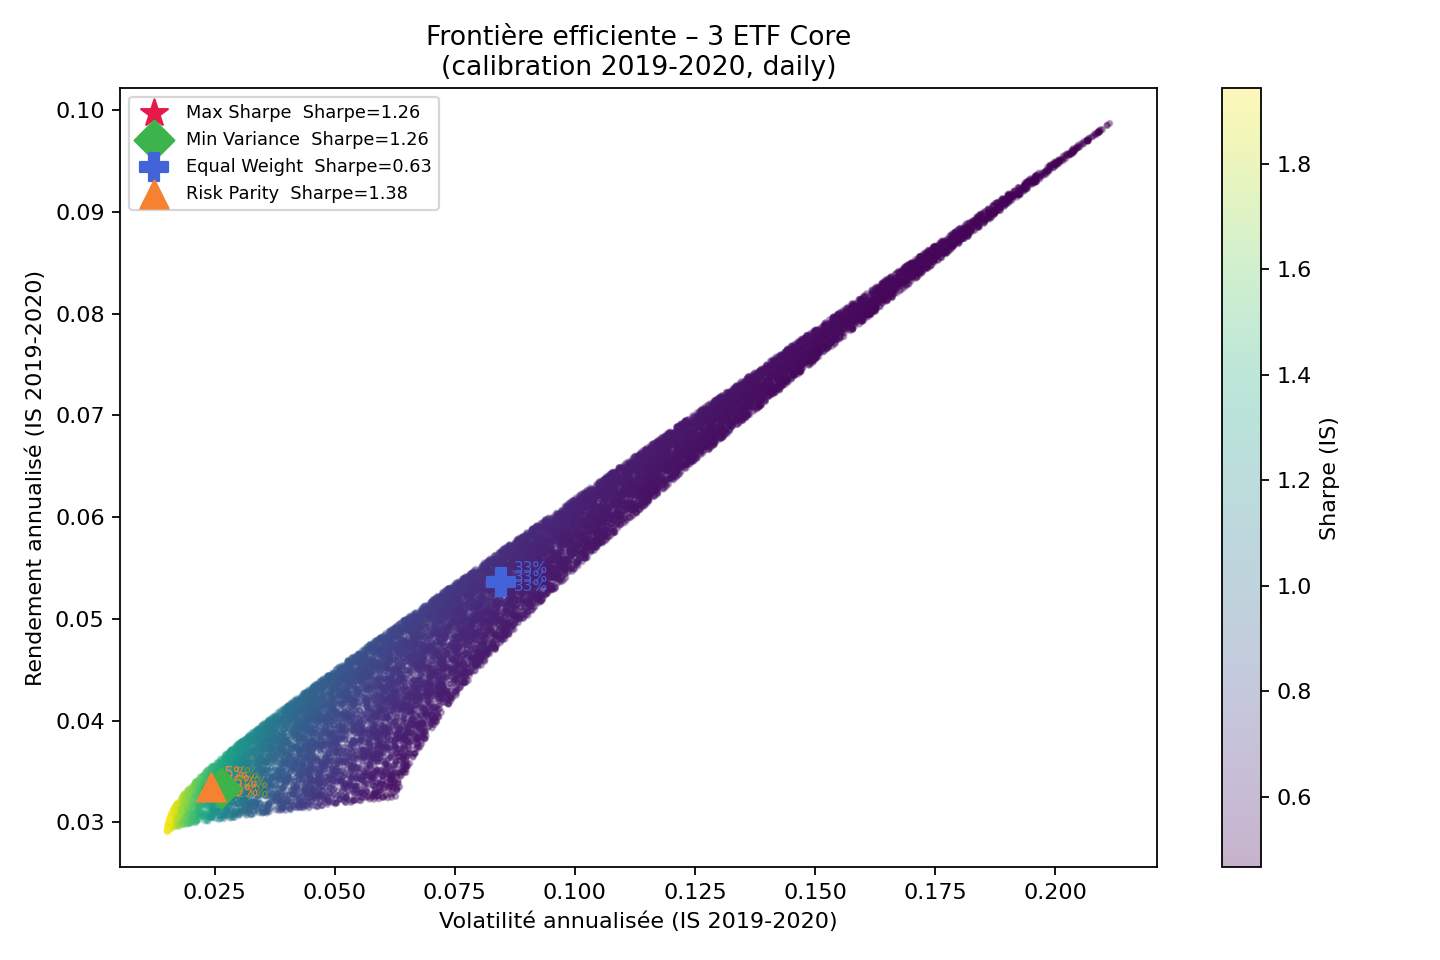

In [7]:
print('Frontière efficiente IS (2019-2020) + 5 stratégies')
display(Image('outputs/figures/06_efficient_frontier_core.png'))

Performance cumulée OOS (2021-2025) des 5 stratégies


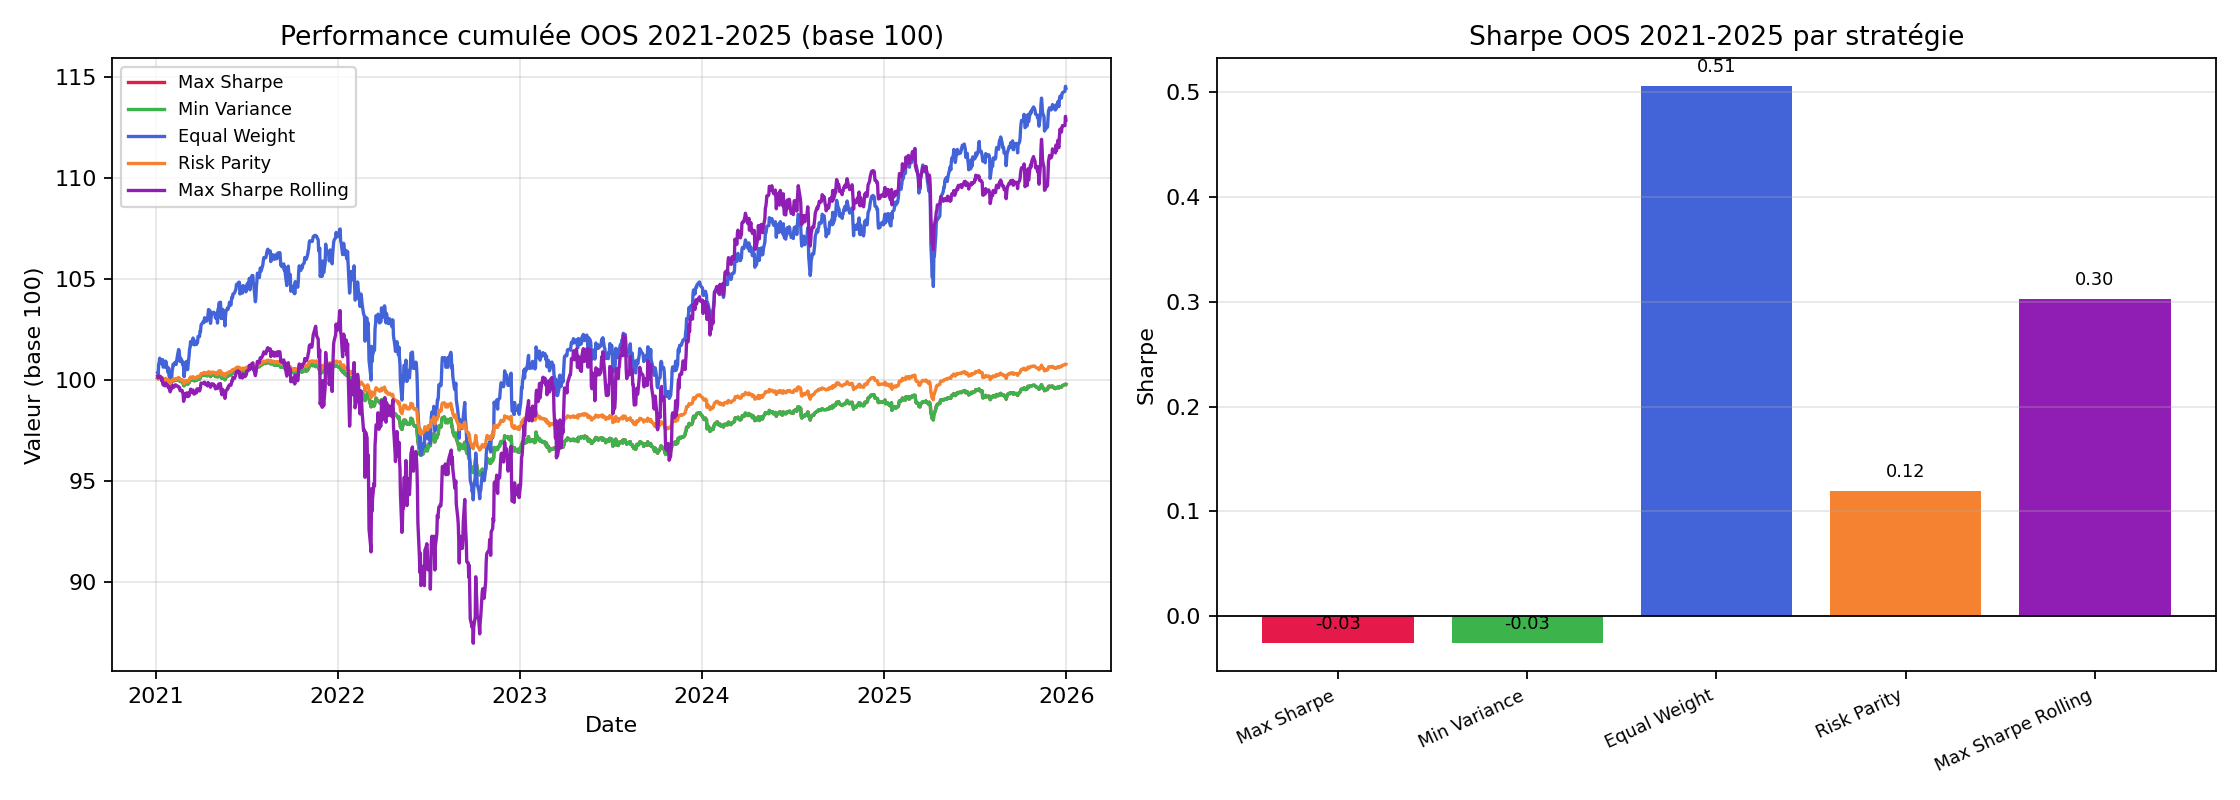

In [8]:
print('Performance cumulée OOS (2021-2025) des 5 stratégies')
display(Image('outputs/figures/07_core_strategies_oos_perf.png'))

---
## Étape 3  Sélection des fonds Satellite

Filtrage en **4 niveaux** sur ~890 fonds alternatifs, organisés en 3 blocs :

- **Bloc 1 (Décorrélation)** : Long Volatilité, Tail Risk, Optionnel  convexité du portefeuille
- **Bloc 2 (Alpha contrôlé)** : Market Neutral, L/S Equity, CTA  alpha systématique, bêta  0.25
- **Bloc 3 (Macro)** : Commodities, ILS/Cat Bonds, ARP  moteurs orthogonaux au cycle

Les niveaux de filtrage :
1. **Structurel** : AUM  100M€, métriques complètes
2. **Frais & Vol** : plafonds adaptés par bloc
3. **Qualité quant** : Sharpe, Alpha, MDD
4. **Distribution** : Skewness, Kurtosis, diversification

In [9]:
import os
os.environ['SAT_ALLOWED_CURRENCIES'] = 'Euro'

from src.satellite_pipeline import main as sat_main
sat_main()


  PIPELINE SATELLITE v2 – Filtrage & Sélection
  Fenêtre calib : 2019-01-01 → 2020-12-31
  Filtre devise : ['Euro']

[1] Chargement des rendements Core...
    2898 obs. daily | 2014-09-22 → 2026-01-08
    Benchmark filtre beta : Core équipondéré (3 ETF sélectionnés via CSV)
    3196 obs. daily | 2013-09-27 → 2026-03-16

  Bloc 1 – Décorrélation / Convexité
  [données] 74 fonds avec prix ET info
  [métriques] Calcul sur calib 2019-01-01 → 2020-12-31...
  [beta init] Rolling 63j vs Core équipondéré...
  [Niv.Beta] |beta| <= 25% sur >= 70% jours     3 / 74
             3 fonds avec données suffisantes
  [Niv.0] AUM/Date/Devise/Excl.    1 / 74
  [Niv.1] Frais & Volatilité       1 / 1
  [Niv.2] Sharpe/Alpha/Drawdown    1 / 1
  [Niv.3] Skew/Kurt/Conc.          0 / 1
  ⚠  Aucun fonds ne passe tous les filtres dans Bloc1.

  Bloc 2 – Alpha avec bêta contrôlé
  [données] 301 fonds avec prix ET info
  [métriques] Calcul sur calib 2019-01-01 → 2020-12-31...
  [beta init] Rolling 63j vs Core équip

In [10]:
sat_sel = pd.read_csv('outputs/satellite_selected.csv').set_index('ticker')

cols_pref = [
    'bloc', 'strategie', 'devise', 'aum_usd_m', 'expense_pct',
    'vol_calib', 'sharpe_calib', 'alpha_annual', 'beta_core',
    'drawdown_calib', 'n_obs_calib'
]
cols_show = [c for c in cols_pref if c in sat_sel.columns]

fmt = {
    'aum_usd_m': '{:,.0f}',
    'expense_pct': '{:.2f}',
    'vol_calib': '{:.2%}',
    'sharpe_calib': '{:.2f}',
    'alpha_annual': '{:.2%}',
    'beta_core': '{:.3f}',
    'drawdown_calib': '{:.2%}',
    'n_obs_calib': '{:.0f}',
}
fmt = {k: v for k, v in fmt.items() if k in cols_show}

print(f"{len(sat_sel)} fonds satellite sélectionnés :")
if len(cols_show) == 0:
    display(sat_sel)
else:
    display(sat_sel[cols_show].sort_values('bloc').style.format(fmt))


5 fonds satellite sélectionnés :


,bloc,strategie,devise,aum_usd_m,expense_pct,vol_calib,sharpe_calib,alpha_annual,beta_core,drawdown_calib,n_obs_calib
ticker,,,,,,,,,,,
PDAIEUR LX Equity,Bloc2,Multi-stratégie,Euro,"2,139",1.56,3.71%,1.31,5.03%,-0.039,-3.82%,441
BLEURAA LX Equity,Bloc2,Equity Hedge,Euro,601,1.86,5.80%,0.80,3.21%,0.270,-4.76%,443
BPAIELI LX Equity,Bloc2,Equity Hedge,Euro,367,1.57,2.88%,0.38,0.60%,0.180,-3.13%,410
DANGIAC LX Equity,Bloc3,Protégé contre l'inflation,Euro,614,1.07,2.81%,1.71,3.01%,0.188,-2.60%,386
NDCBBXE LX Equity,Bloc3,Titres adossés à des actifs,Euro,126,0.06,2.11%,1.49,2.37%,0.104,-2.42%,383


---
## Étape 4 — Construction et backtest du fonds Core-Satellite

**Principes :**
- **Poche Core (70-75 %)** : stratégie Max-Sharpe Rolling sur les 3 ETF
- **Poche Satellite (25-30 %)** : allocation **equal-weight (1/n)** sur les fonds retenus
- Calibration de w_core / w_sat sur 2019-2020 pour atteindre la vol cible [4%, 15%]
- Rebalancement trimestriel (tous les 63 jours ouvrés)
- Seuls les fonds avec données en période de calibration **et** de backtest sont retenus

**Backtest out-of-sample** : 01/01/2021 → 31/12/2025

In [11]:
from src.fond_construction import main as fond_main
fond_main()

  CONSTRUCTION DU FONDS CORE-SATELLITE
  Calibration : 2019-01-01 → 2020-12-31
  Backtest    : 2021-01-01 → 2025-12-31

[1] Chargement des données...
  ⚠  Estimation frais Core impossible (Worksheet named 'Worksheet' not found); fallback 23.0 bps.
    Core  : 2898 obs. | 2014-09-22 → 2026-01-08
    Satellite : 5 fonds | 2010-01-01 → 2025-12-31
    Couverture par période :
      PDAIEUR LX Equity               calib=501 obs  oos=1251 obs  ✓
      BLEURAA LX Equity               calib=502 obs  oos=1253 obs  ✓
      BPAIELI LX Equity               calib=476 obs  oos=1256 obs  ✓
      DANGIAC LX Equity               calib=500 obs  oos=1249 obs  ✓
      NDCBBXE LX Equity               calib=497 obs  oos= 800 obs  ✓

  Blocs (2) : {'Bloc2': 3, 'Bloc3': 2}

[2] Allocation equal-weight des poids satellite...
  Fonds retenus : 5 / 5
  Poids par fonds (equal-weight) : 20.0%

  Poids satellite (equal-weight 1/n) :
    PDAIEUR LX Equity                20.0%   [Bloc2 – Multi-stratégie]
    BLEURAA 

In [12]:
metrics = pd.read_csv('outputs/fond_metrics.csv', index_col=0)
print('Métriques du fonds Core-Satellite (OOS 2021-2025) :')
display(metrics.style.format('{:.4f}'))

Métriques du fonds Core-Satellite (OOS 2021-2025) :


,valeur
vol_portfolio_ann,0.0460
ret_ann_portfolio,0.0178
sharpe_portfolio,0.3862
max_drawdown,-0.1053
alpha_portfolio_ann,0.0027
beta_portfolio,0.7686
vol_core_ann,0.0595
ret_ann_core,0.0193
sharpe_core,0.3236
vol_satellite_ann,0.0210


In [13]:
w_df = pd.read_csv('outputs/fond_weights.csv', index_col=0)
print('Poids de la poche satellite (theta = poids dans la poche, poids_absolu = w_sat  theta) :')
display(w_df.style.format('{:.4f}').bar(subset=['theta_satellite'], color='#3cb44b').bar(subset=['w_sat'], color='#4363d8'))

Poids de la poche satellite (theta = poids dans la poche, poids_absolu = w_sat  theta) :


,theta_satellite,absolute_weight,w_core,w_sat,portfolio_scale
PDAIEUR LX Equity,0.2000,0.0500,0.7500,0.2500,1.0000
BLEURAA LX Equity,0.2000,0.0500,0.7500,0.2500,1.0000
BPAIELI LX Equity,0.2000,0.0500,0.7500,0.2500,1.0000
DANGIAC LX Equity,0.2000,0.0500,0.7500,0.2500,1.0000
NDCBBXE LX Equity,0.2000,0.0500,0.7500,0.2500,1.0000


In [14]:
ann = pd.read_csv('outputs/fond_annual_perf.csv', index_col=0)
ann.index = ann.index.astype(int)
print('Performance annuelle :')
display(ann.style.format('{:.2%}')
        .map(lambda v: 'color: green' if v > 0 else 'color: red')
        .highlight_max(axis=0, color='lightgreen')
        .highlight_min(axis=0, color='lightyellow'))

Performance annuelle :


,portfolio,core,satellite
2021,2.15%,1.94%,2.78%
2022,-6.21%,-6.32%,-5.98%
2023,6.42%,7.23%,3.98%
2024,4.70%,4.93%,3.98%
2025,2.48%,2.56%,2.24%


---
## Étape 5  Visualisations complètes

Génération de **24 graphiques** organisés en 4 sections :

| Section | Figures | Contenu |
|---------|---------|--------|
| **A**  Poche Core | A01A07 | ETF individuels, portefeuille, drawdown, vol rolling, Sharpe, annuel, frais |
| **B**  Poche Satellite | B01B07 | Fonds individuels, poche agrégée, poids, alpha/beta rolling, annuel, frais |
| **C**  Core vs Satellite | C01C04 | Comparaison cumulée, excès, performance annuelle groupée |
| **D**  Portefeuille total | D01D06 | Performance, drawdown, annuel, vol vs cible, beta satellite, distribution |

  GÉNÉRATION DES GRAPHIQUES – RAPPORT CORE-SATELLITE

[1] Chargement des données...
    Backtest : 2021-01-04 → 2025-12-31 (1283 obs)

[2] Section A – Poche Core (7 figures)...


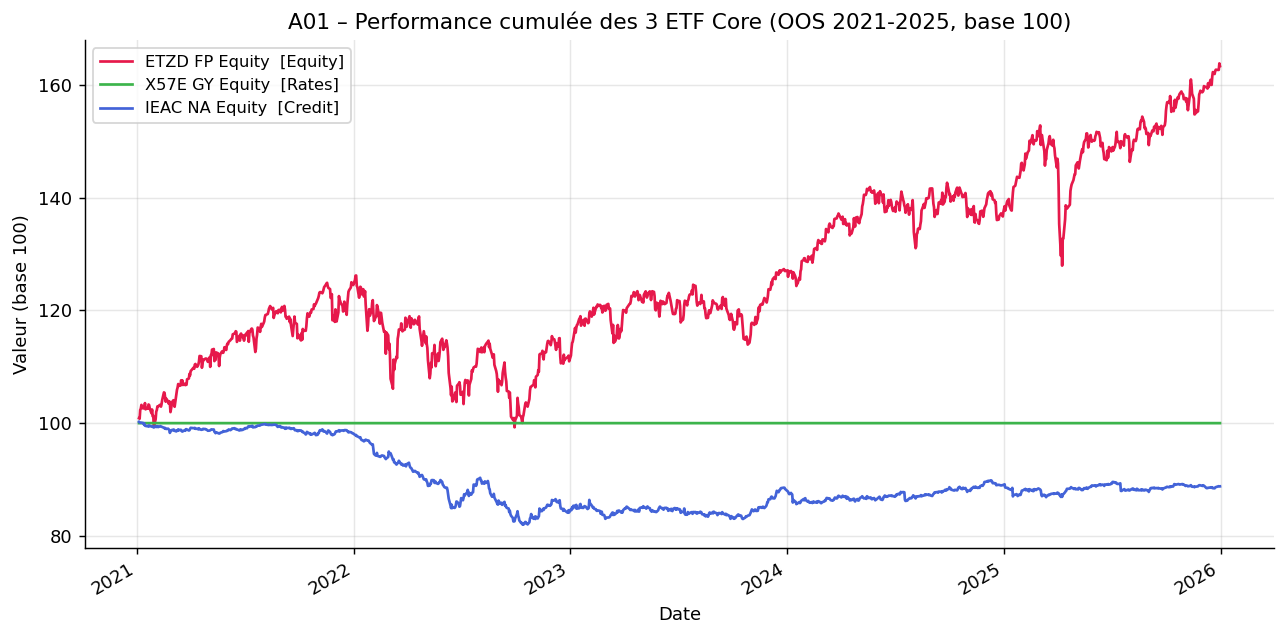

  -> /Users/naz/Desktop/Core_Satellite_Quant/outputs/figures/A01_core_etf_cum.png


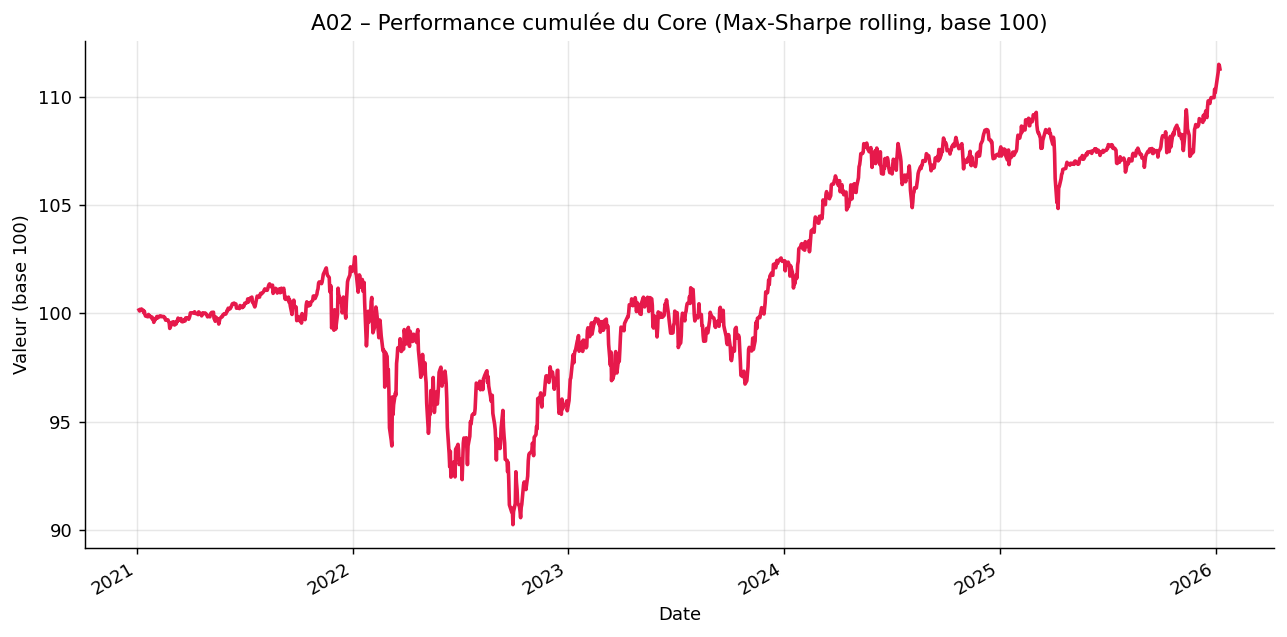

  -> /Users/naz/Desktop/Core_Satellite_Quant/outputs/figures/A02_core_portfolio_cum.png


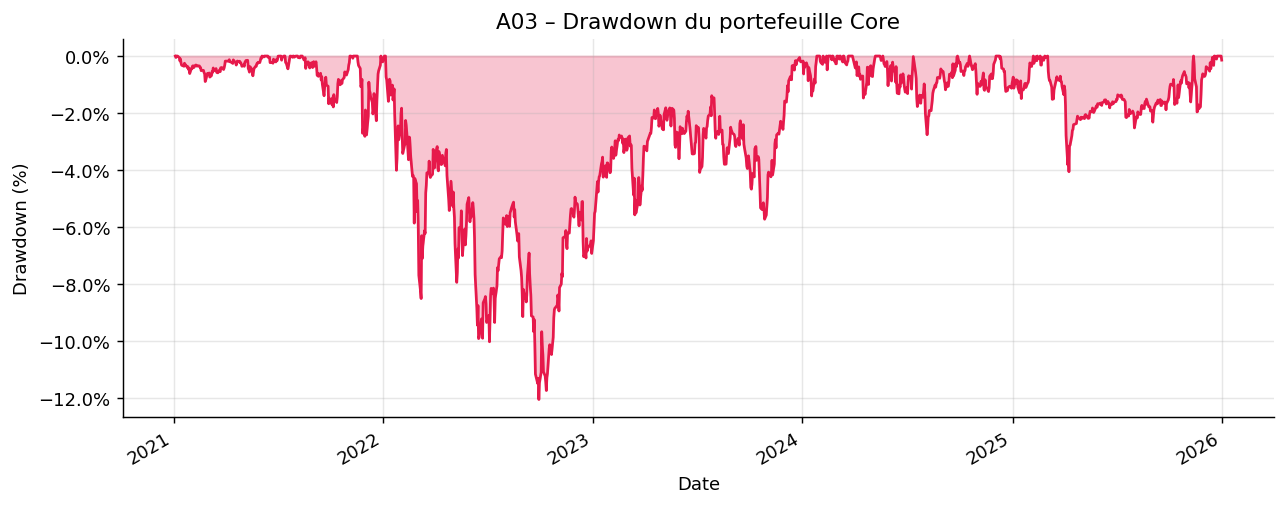

  -> /Users/naz/Desktop/Core_Satellite_Quant/outputs/figures/A03_core_drawdown.png


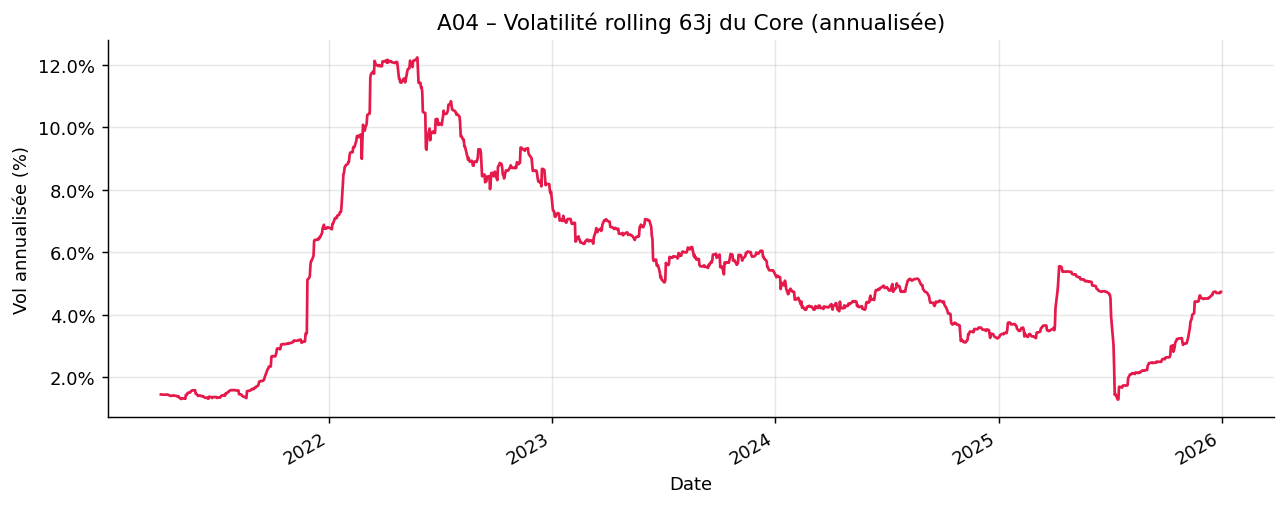

  -> /Users/naz/Desktop/Core_Satellite_Quant/outputs/figures/A04_core_rolling_vol.png


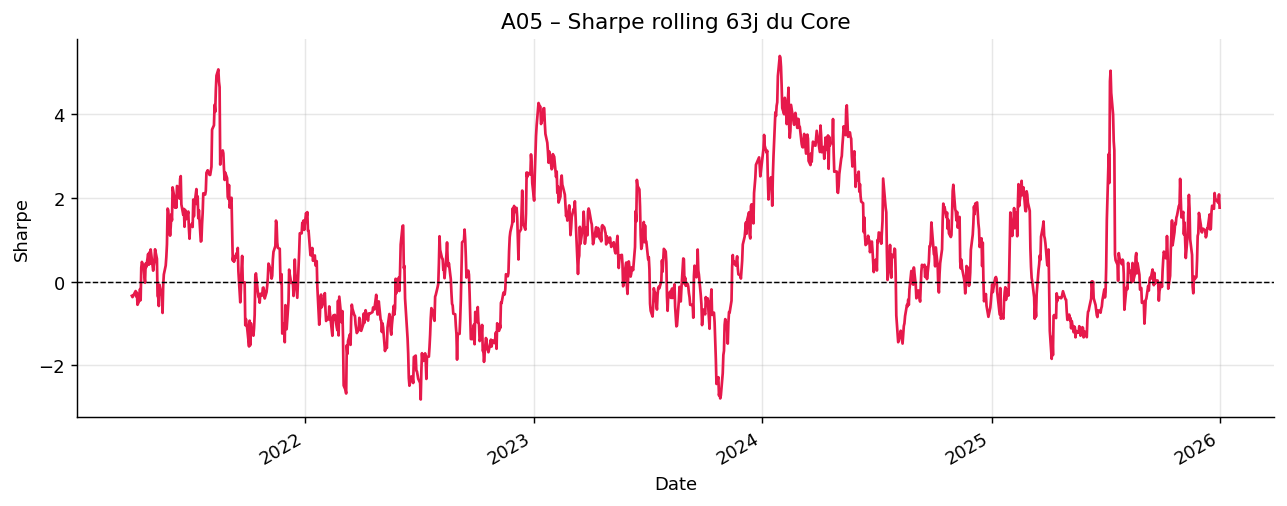

  -> /Users/naz/Desktop/Core_Satellite_Quant/outputs/figures/A05_core_rolling_sharpe.png


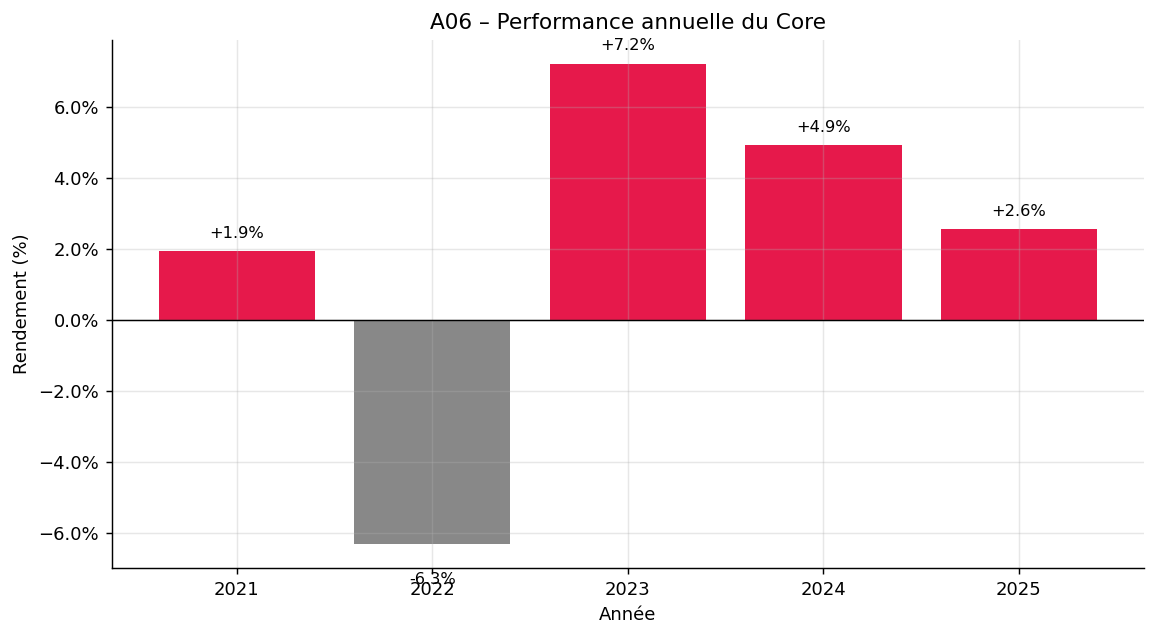

  -> /Users/naz/Desktop/Core_Satellite_Quant/outputs/figures/A06_core_annual_bar.png


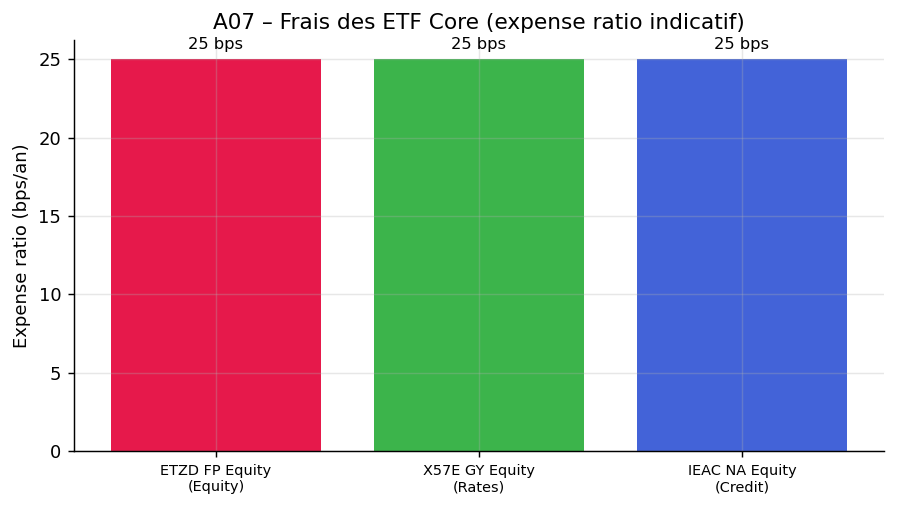

  -> /Users/naz/Desktop/Core_Satellite_Quant/outputs/figures/A07_core_fees_bar.png

[3] Section B – Poche Satellite (7 figures)...


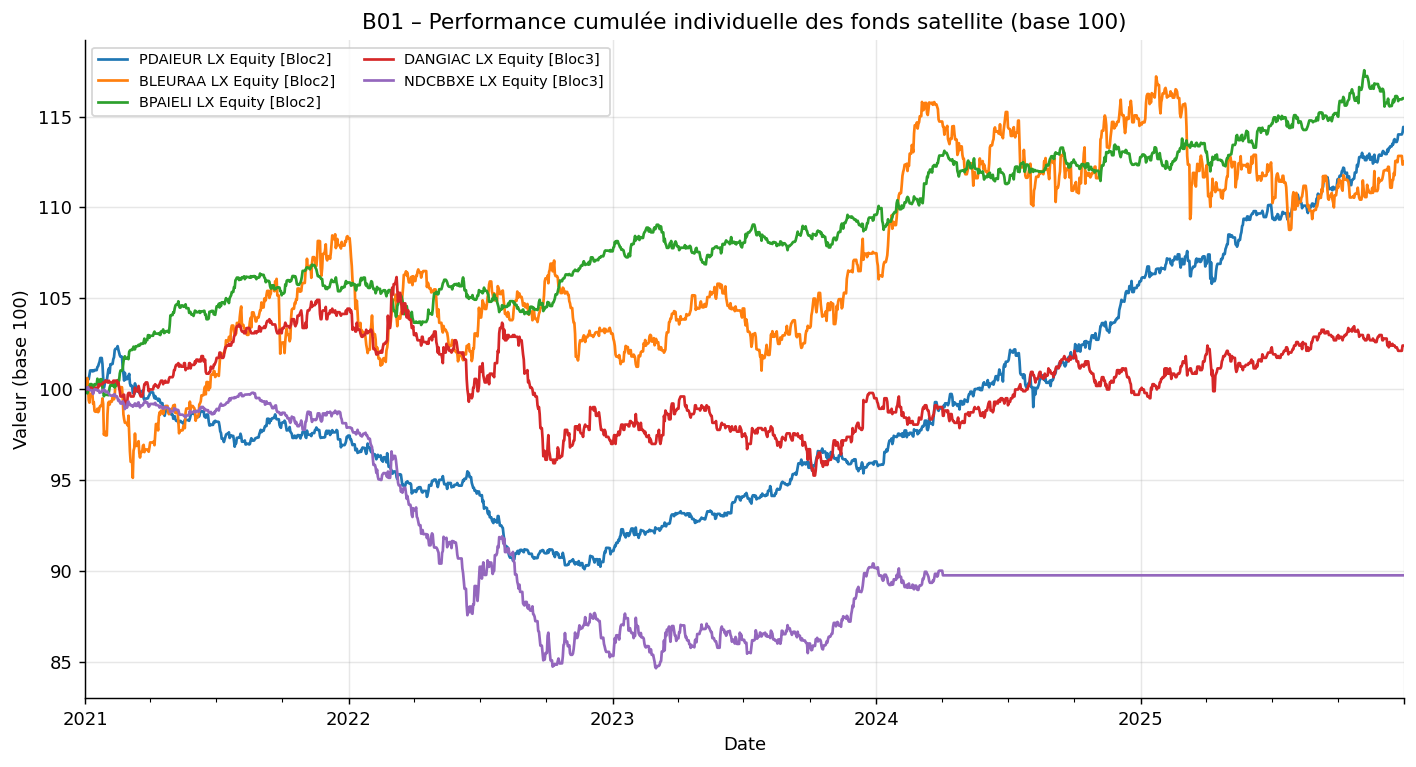

  -> /Users/naz/Desktop/Core_Satellite_Quant/outputs/figures/B01_sat_fund_cum.png


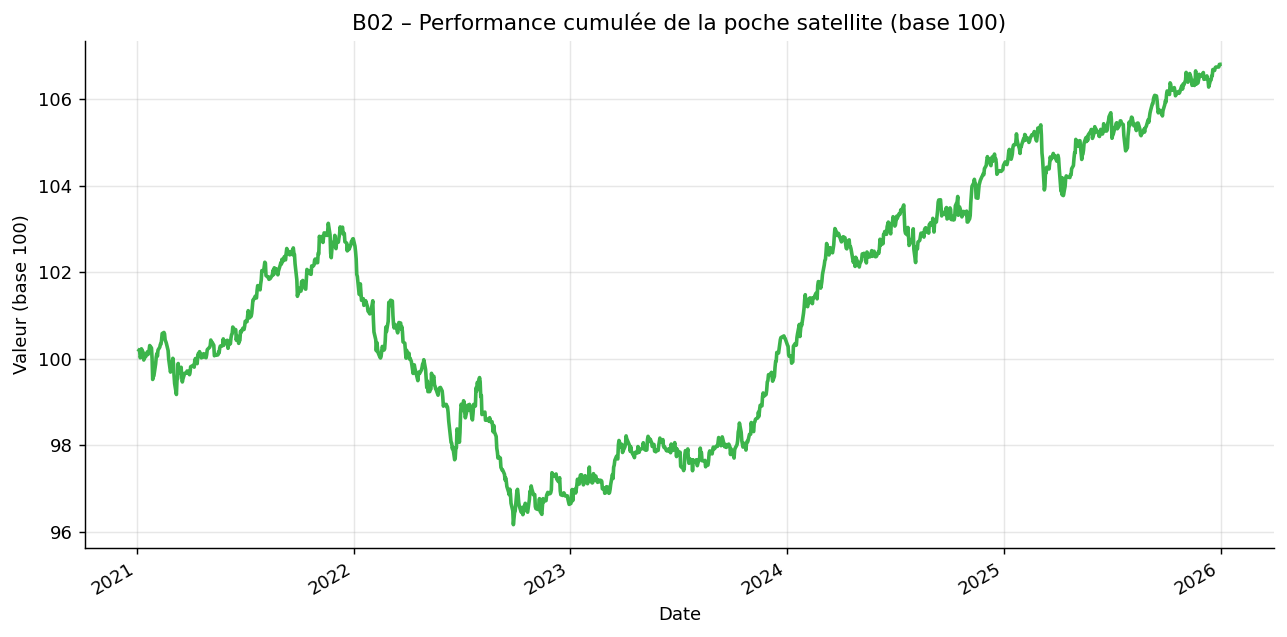

  -> /Users/naz/Desktop/Core_Satellite_Quant/outputs/figures/B02_sat_pocket_cum.png


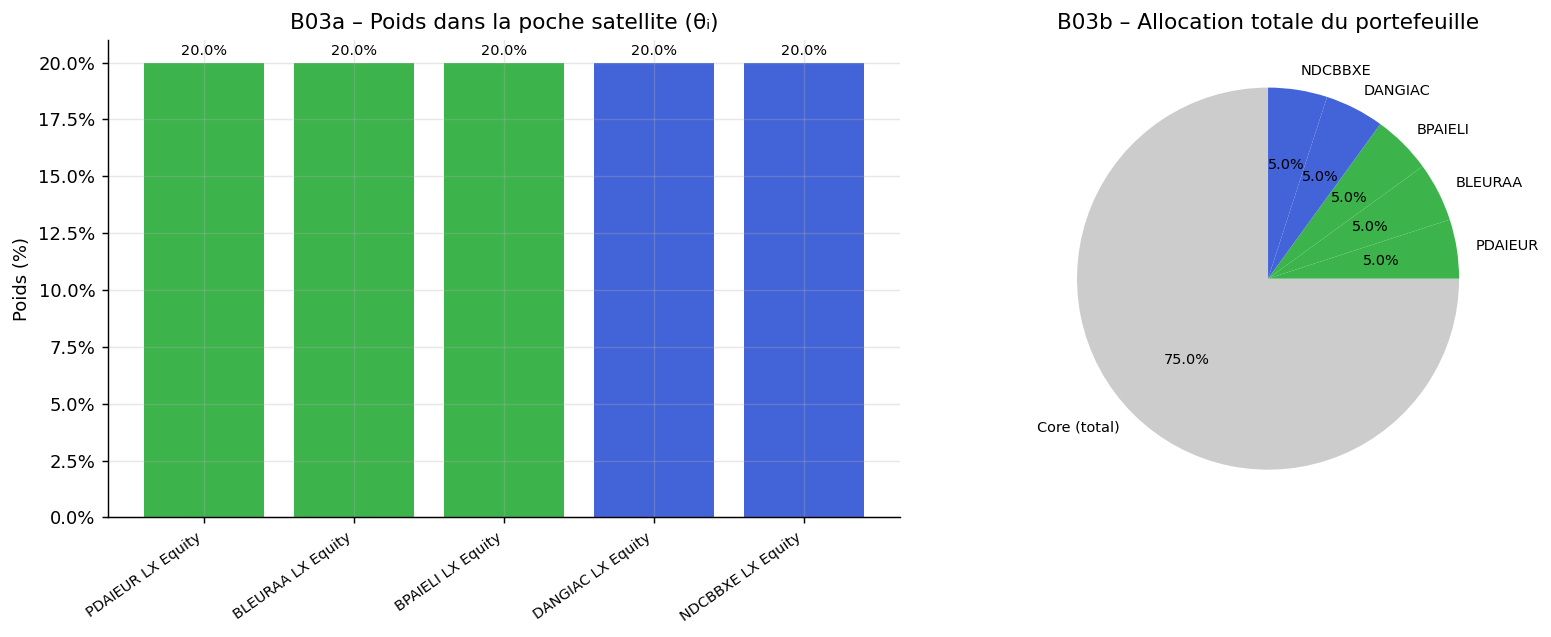

  -> /Users/naz/Desktop/Core_Satellite_Quant/outputs/figures/B03_sat_weights.png


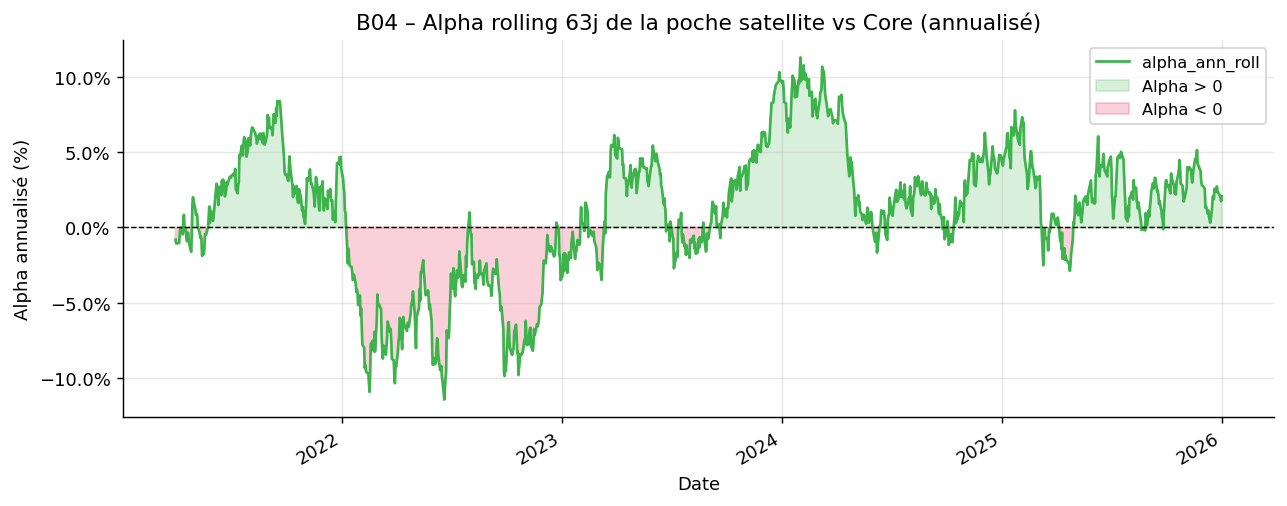

  -> /Users/naz/Desktop/Core_Satellite_Quant/outputs/figures/B04_sat_rolling_alpha.png


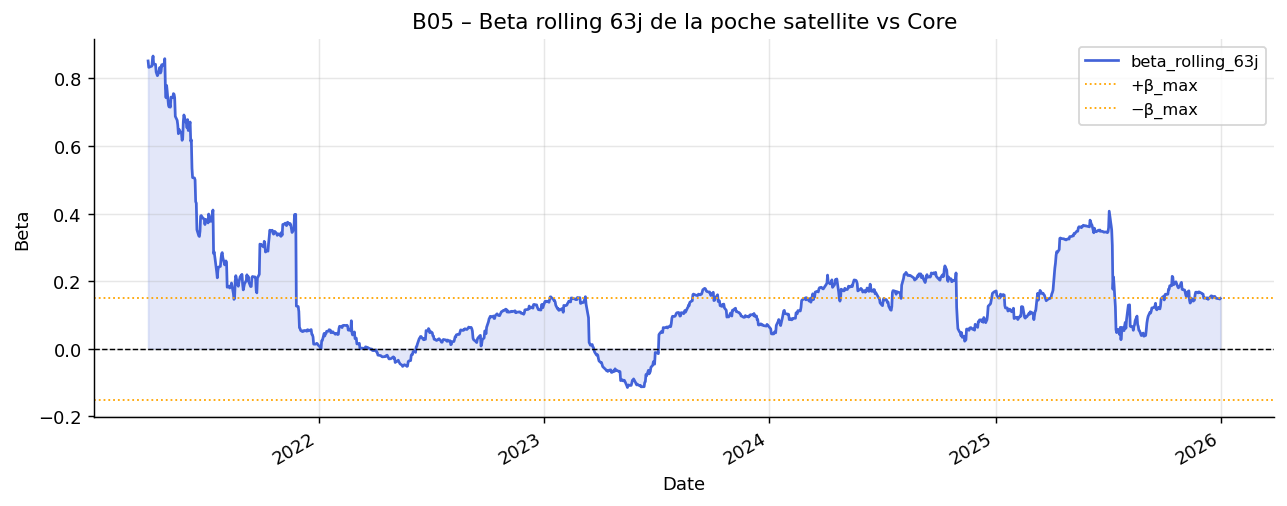

  -> /Users/naz/Desktop/Core_Satellite_Quant/outputs/figures/B05_sat_rolling_beta.png


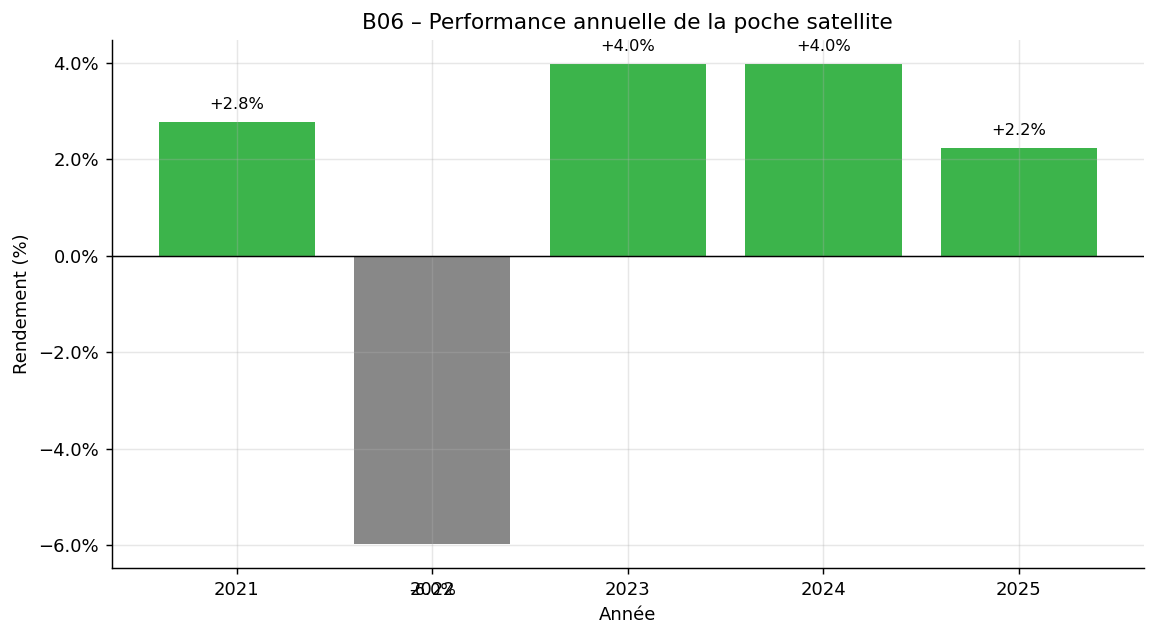

  -> /Users/naz/Desktop/Core_Satellite_Quant/outputs/figures/B06_sat_annual.png


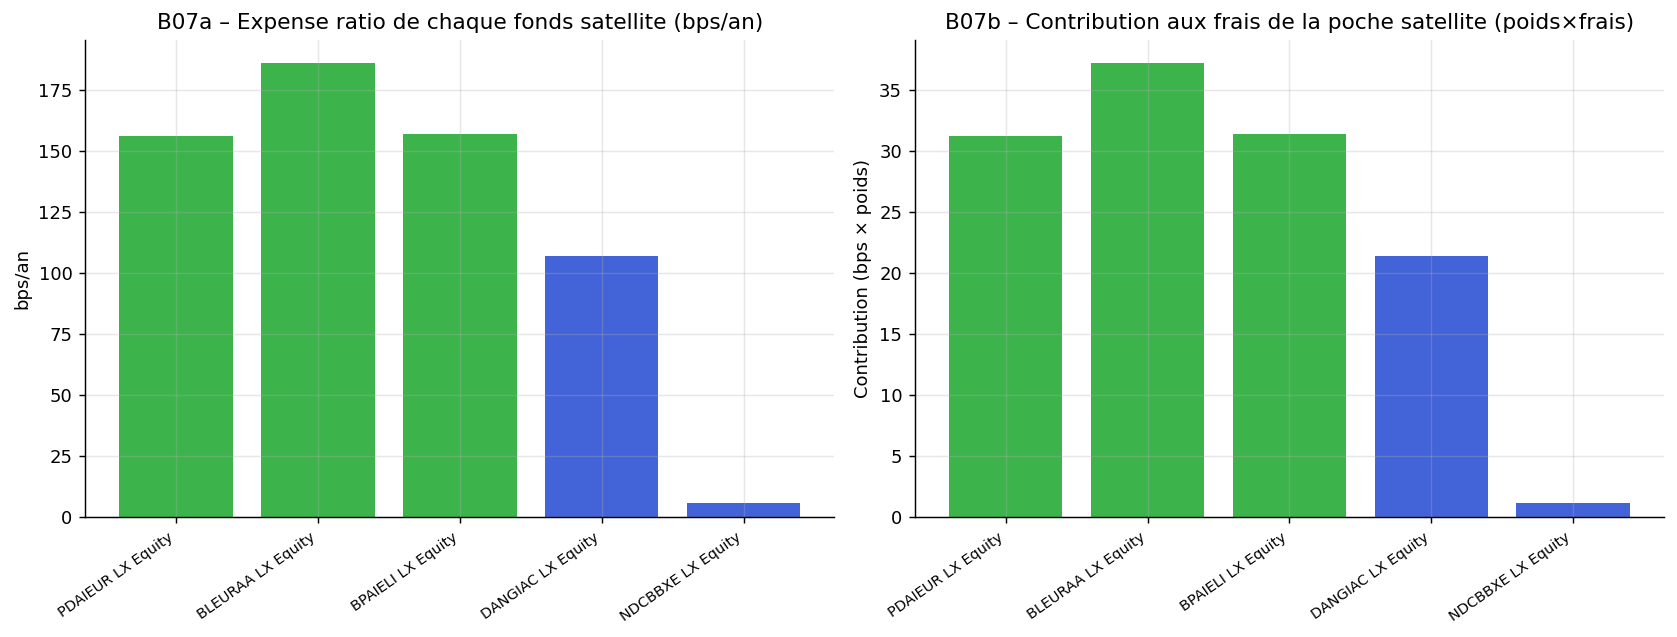

  -> /Users/naz/Desktop/Core_Satellite_Quant/outputs/figures/B07_sat_fees.png

[4] Section C – Core vs Satellite (4 figures)...


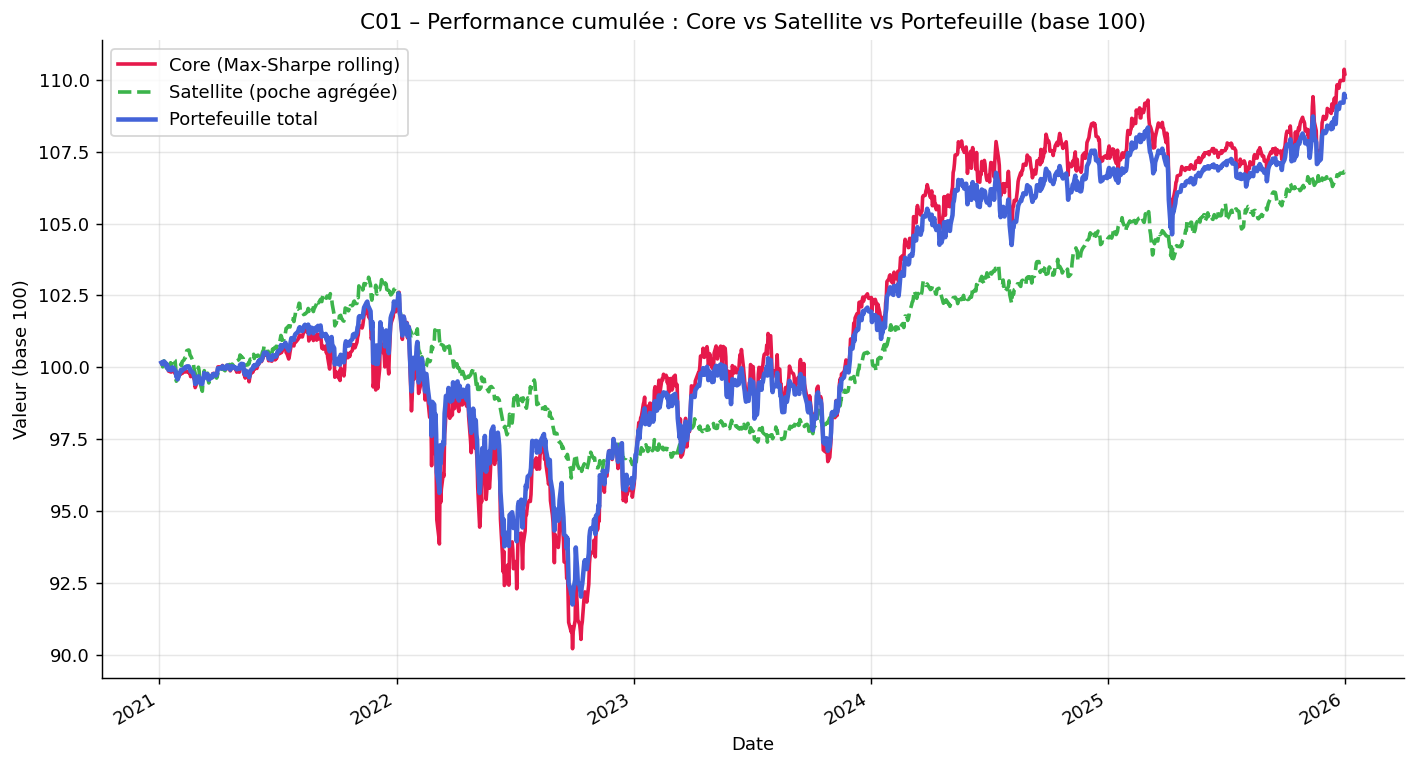

  -> /Users/naz/Desktop/Core_Satellite_Quant/outputs/figures/C01_core_vs_sat_cum.png


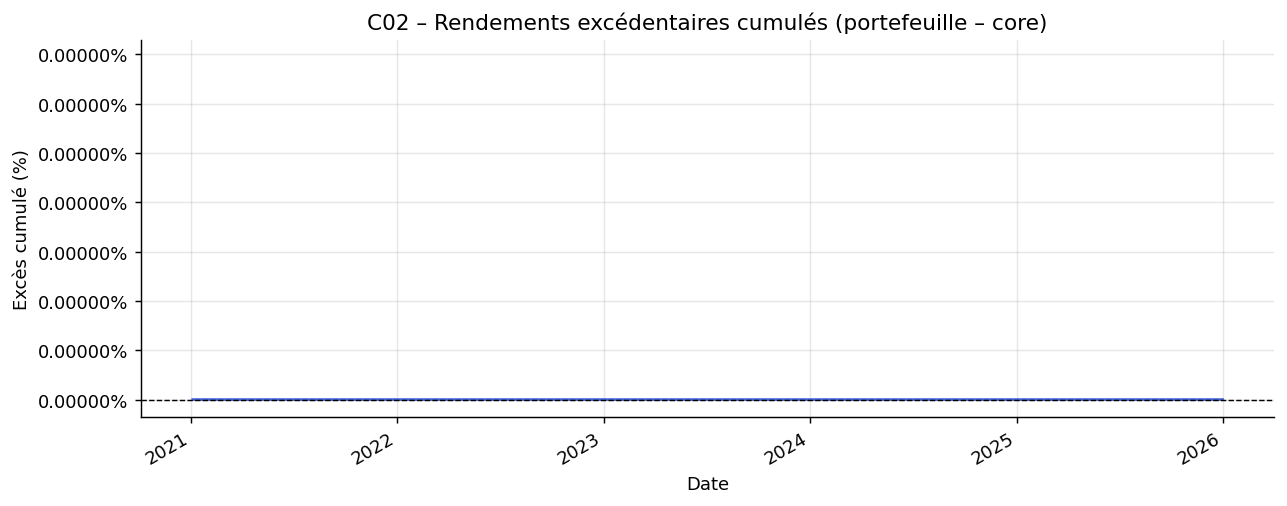

  -> /Users/naz/Desktop/Core_Satellite_Quant/outputs/figures/C02_excess_cum.png


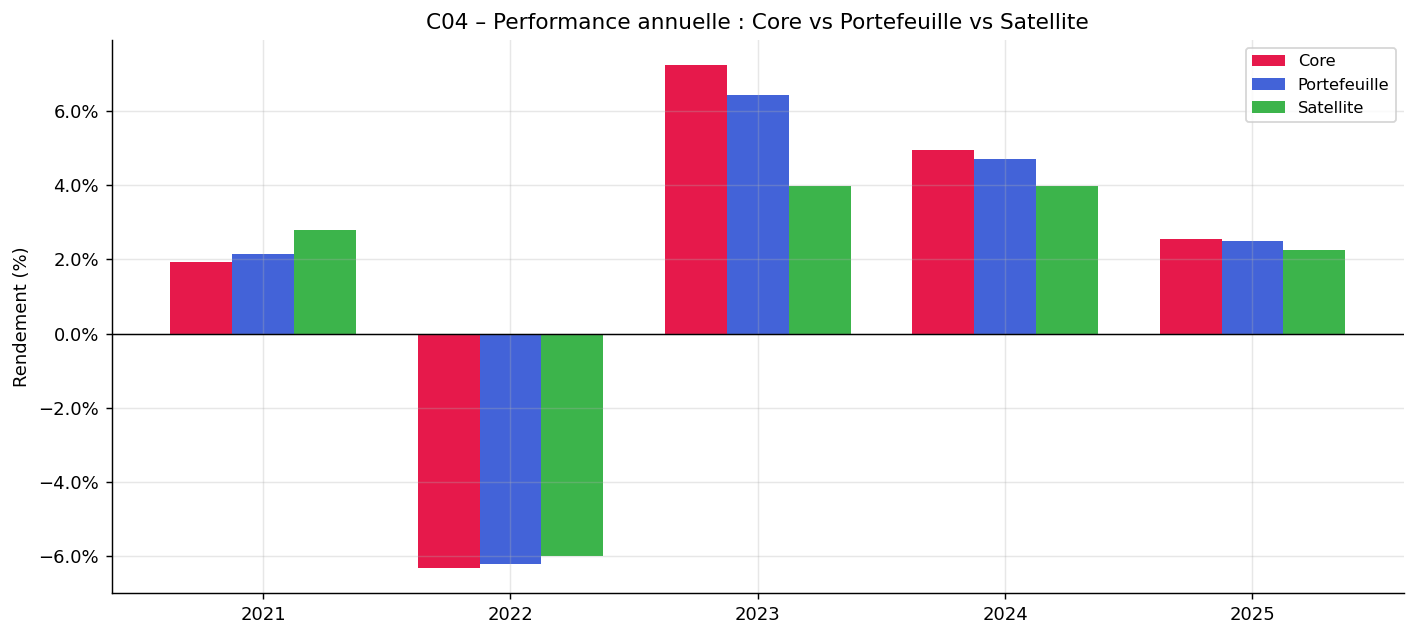

  -> /Users/naz/Desktop/Core_Satellite_Quant/outputs/figures/C04_annual_grouped_bar.png


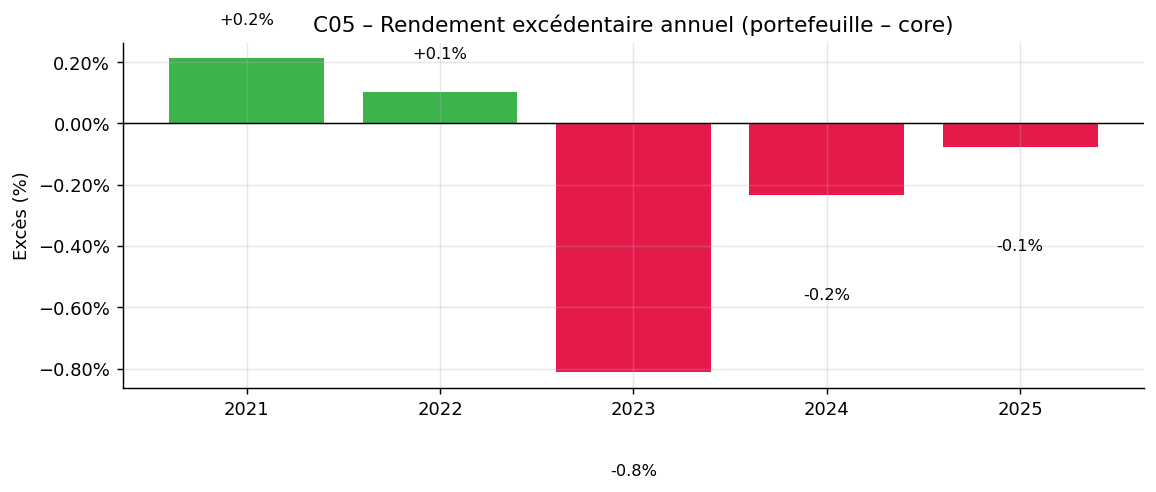

  -> /Users/naz/Desktop/Core_Satellite_Quant/outputs/figures/C05_excess_annual.png

[5] Section D – Portefeuille total (6 figures)...


/Users/naz/Desktop/Core_Satellite_Quant/.venv/lib/python3.13/site-packages/pandas/plotting/_matplotlib/core.py:997: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


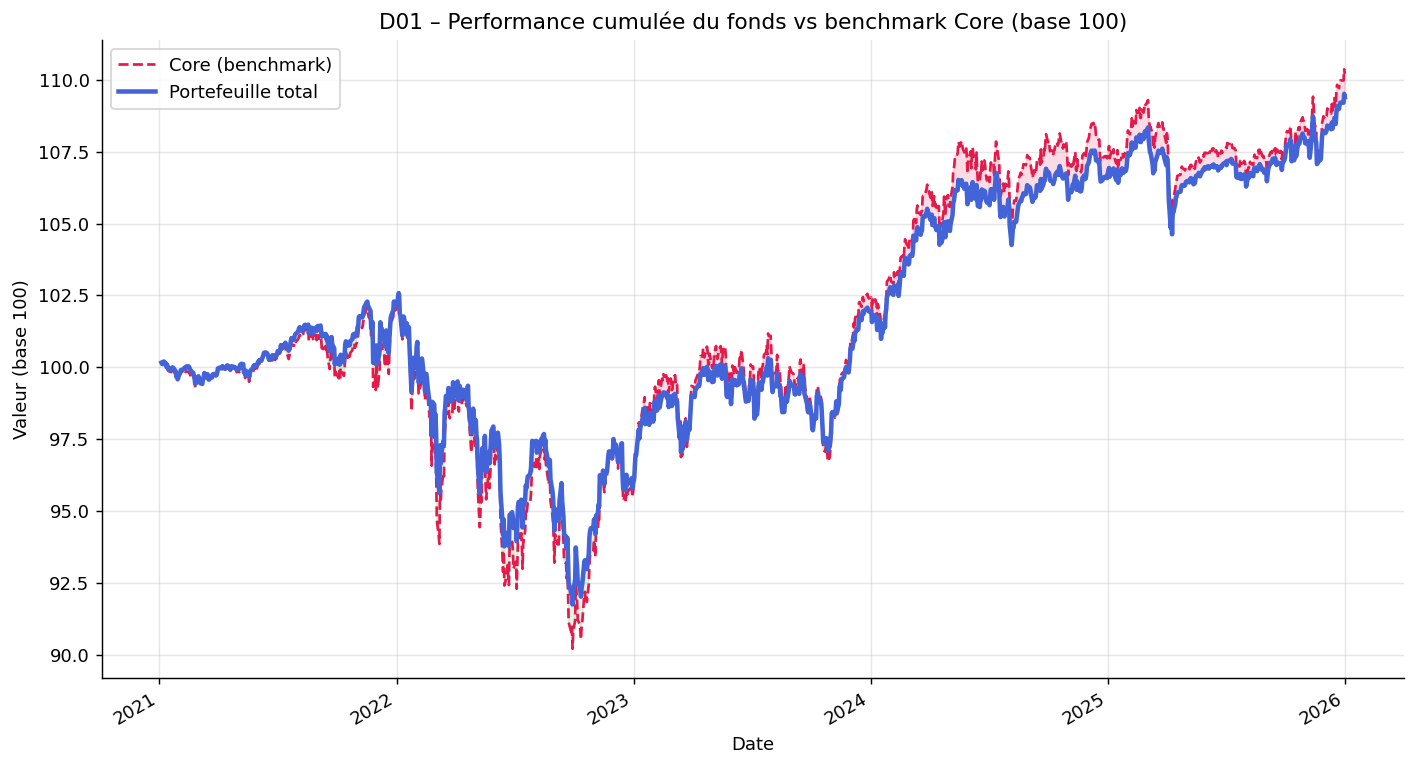

  -> /Users/naz/Desktop/Core_Satellite_Quant/outputs/figures/D01_portfolio_cum.png


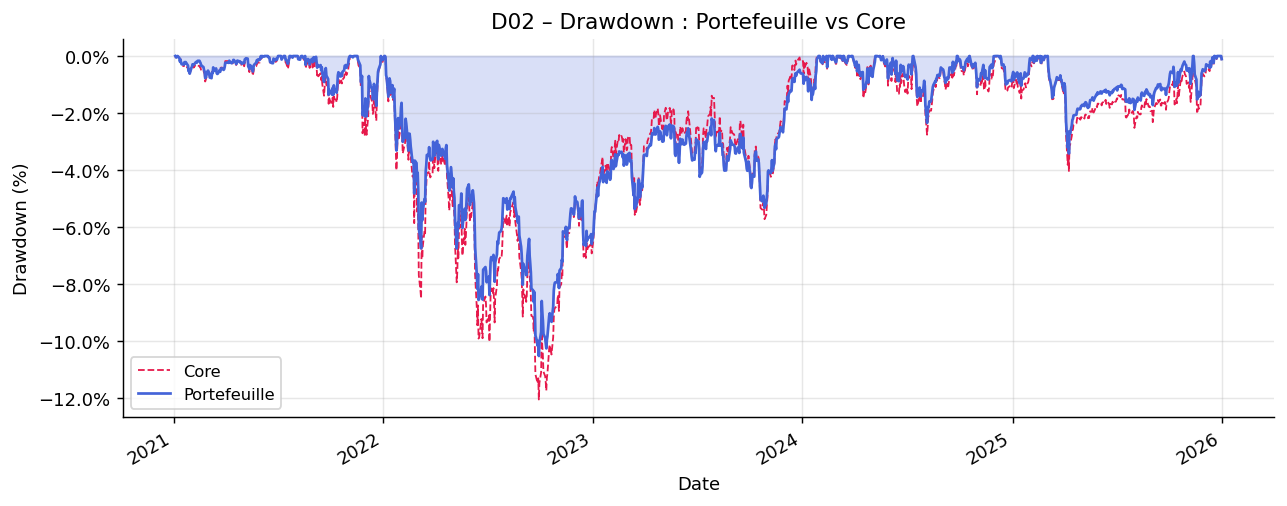

  -> /Users/naz/Desktop/Core_Satellite_Quant/outputs/figures/D02_portfolio_drawdown.png


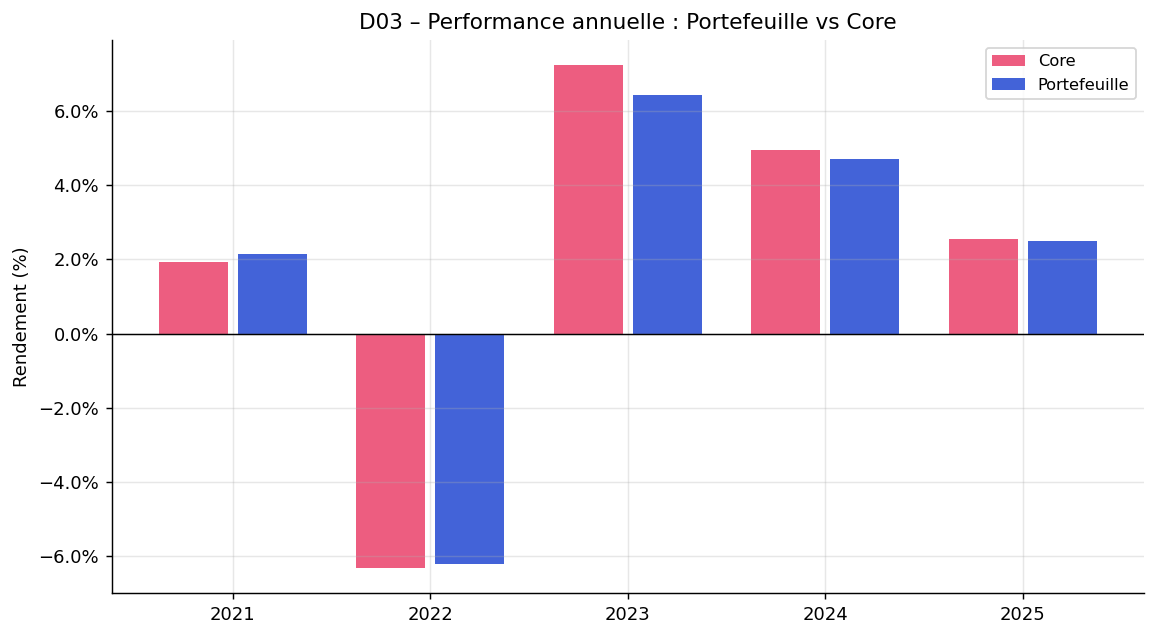

  -> /Users/naz/Desktop/Core_Satellite_Quant/outputs/figures/D03_portfolio_annual.png


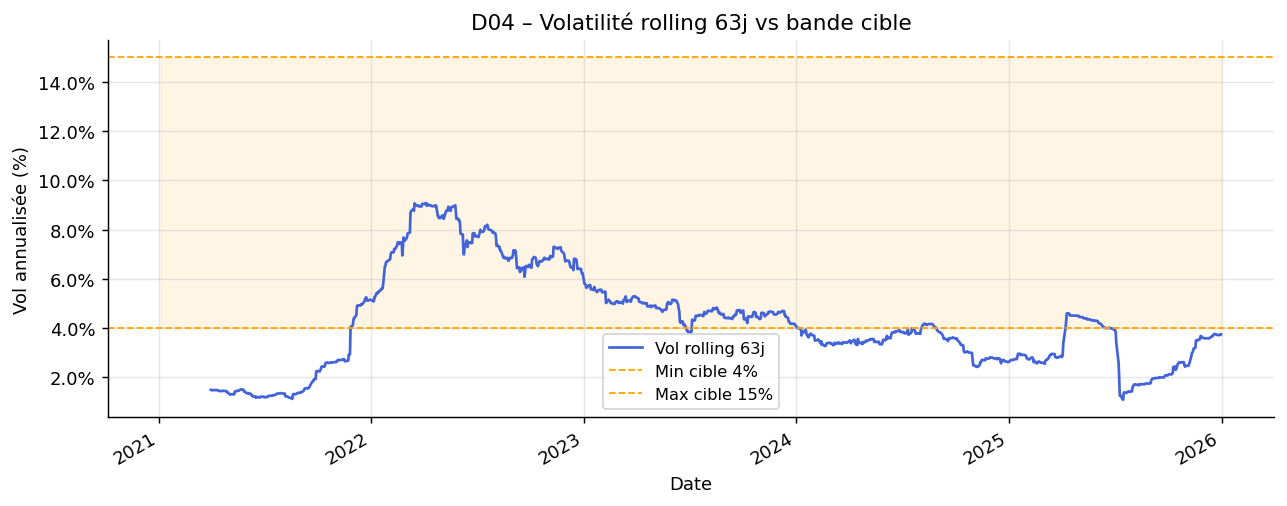

  -> /Users/naz/Desktop/Core_Satellite_Quant/outputs/figures/D04_portfolio_vol_target.png


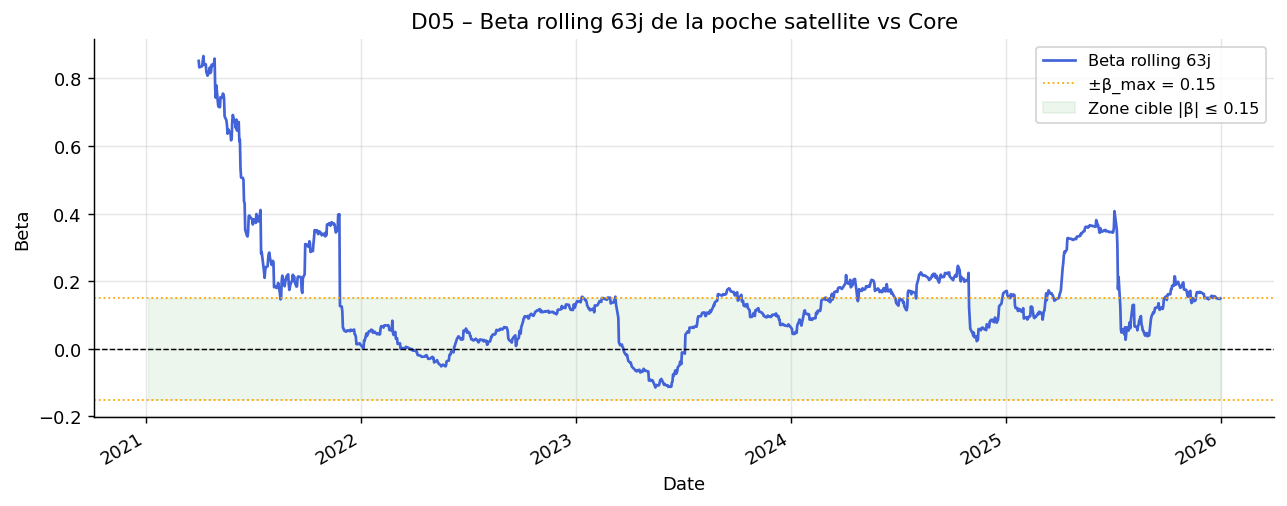

  -> /Users/naz/Desktop/Core_Satellite_Quant/outputs/figures/D05_beta_sat_rolling.png


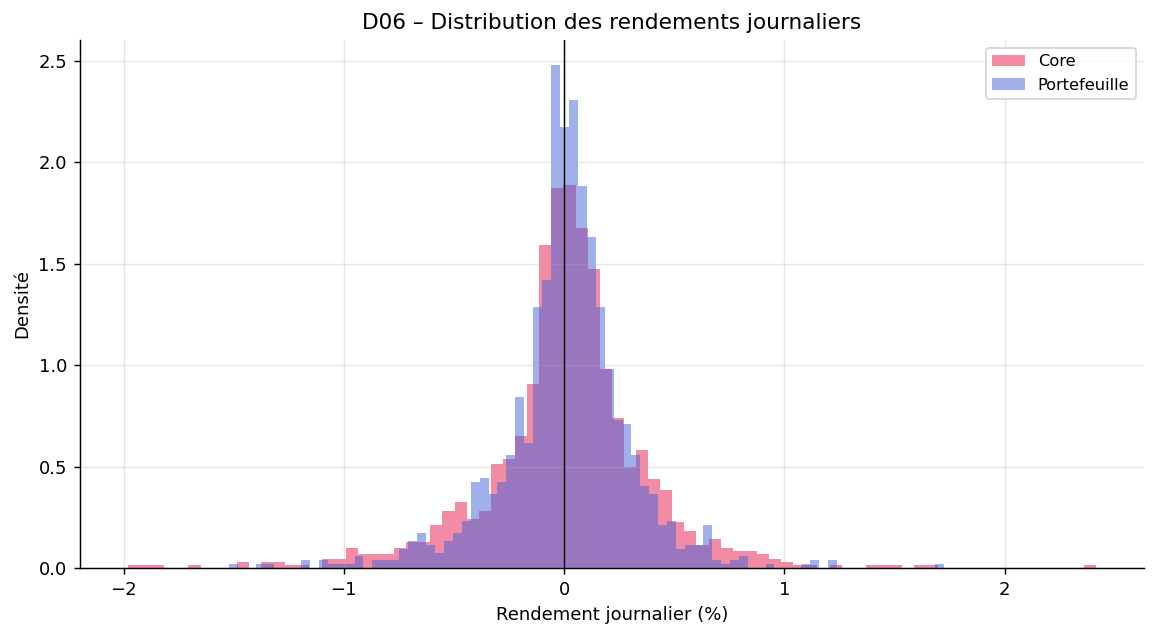

  -> /Users/naz/Desktop/Core_Satellite_Quant/outputs/figures/D06_portfolio_dist.png

  ✓  24 figures générées dans /Users/naz/Desktop/Core_Satellite_Quant/outputs/figures


In [15]:
from src.plots_report import main as plots_main
plots_main()

---
## Récapitulatif  Tableau de bord des métriques clés

Tableau synthétique IS vs OOS pour les 5 stratégies Core + le portefeuille total.

In [16]:

# ── Comparaison des 5 stratégies Core ──────────────────────────────────────
comp = pd.read_csv('outputs/core_portfolio_comparison.csv', index_col=0)
rename = {
    'IS_ret_ann':  'Rdt IS',   'IS_vol_ann':  'Vol IS',   'IS_sharpe':   'Sharpe IS',
    'OOS_ret_ann': 'Rdt OOS',  'OOS_vol_ann': 'Vol OOS',  'OOS_sharpe':  'Sharpe OOS',
    'OOS_mdd':     'MDD OOS',
}
comp = comp.rename(columns=rename)
pct_cols = [c for c in comp.columns if c not in ['Sharpe IS', 'Sharpe OOS', 'poids']]
fmt = {c: '{:.1%}' for c in pct_cols}
fmt.update({'Sharpe IS': '{:.2f}', 'Sharpe OOS': '{:.2f}'})

print('=== Comparaison des 5 stratégies Core (IS 2019-2020 / OOS 2021-2025) ===')
display(comp.drop(columns=['poids'], errors='ignore').style.format(fmt)
        .highlight_max(subset=['Rdt OOS', 'Sharpe OOS'], color='lightgreen')
        .highlight_min(subset=['MDD OOS', 'Vol OOS'],    color='lightblue'))

# ── Métriques complètes du portefeuille global Core-Satellite ───────────────
m = pd.read_csv('outputs/fond_metrics.csv', index_col=0)

# --- Bloc 1 : Rendement / Risque / Drawdown ---------------------------------
perf_data = {
    'Rendement ann.':       (m.loc['ret_ann_portfolio',    m.columns[0]], True),
    'Volatilité ann.':      (m.loc['vol_portfolio_ann',    m.columns[0]], True),
    'Sharpe':               (m.loc['sharpe_portfolio',     m.columns[0]], False),
    'Max Drawdown':         (m.loc['max_drawdown',         m.columns[0]], True),
}
perf_df = pd.DataFrame({
    'Portefeuille total': {k: f"{v:.2%}" if pct else f"{v:.3f}" for k, (v, pct) in perf_data.items()},
    'Poche Core': {
        'Rendement ann.': f"{m.loc['ret_ann_core', m.columns[0]]:.2%}",
        'Volatilité ann.': f"{m.loc['vol_core_ann', m.columns[0]]:.2%}",
        'Sharpe': f"{m.loc['sharpe_core', m.columns[0]]:.3f}",
        'Max Drawdown': '—',
    },
    'Poche Satellite': {
        'Rendement ann.': f"{m.loc['ret_ann_satellite', m.columns[0]]:.2%}",
        'Volatilité ann.': f"{m.loc['vol_satellite_ann', m.columns[0]]:.2%}",
        'Sharpe': '—',
        'Max Drawdown': '—',
    },
})

print('\n\n=== TABLEAU DE BORD – Portefeuille Core-Satellite (OOS 2021-2025) ===\n')
print('── Rendement / Risque ──')
display(perf_df)

# --- Bloc 2 : Alpha / Beta vs Core -----------------------------------------
ab_data = {
    'Alpha (ann.) vs Core': f"{m.loc['alpha_portfolio_ann', m.columns[0]]:.2%}",
    'Beta vs Core':         f"{m.loc['beta_portfolio',      m.columns[0]]:.3f}",
}
ab_df = pd.DataFrame(ab_data, index=['Portefeuille']).T
ab_df.columns.name = ''
print('\n── Alpha / Beta vs Core ──')
display(ab_df)

# --- Bloc 3 : Satellite Beta + Corrélation -----------------------------------
beta_data = {
    'Alpha sat. ann. vs Core': f"{m.loc['alpha_satellite_ann', m.columns[0]]:.2%}",
    'Beta sat. statique':      f"{m.loc['beta_satellite_static', m.columns[0]]:.3f}",
    'Beta sat. rolling moy.':  f"{m.loc['beta_sat_rolling_mean', m.columns[0]]:.3f}",
    'Beta sat. rolling std.':  f"{m.loc['beta_sat_rolling_std',  m.columns[0]]:.3f}",
    'ρ(Core, Satellite)':      f"{m.loc['corr_core_satellite',   m.columns[0]]:.3f}",
}
beta_df = pd.DataFrame(beta_data, index=['Satellite']).T
beta_df.columns.name = ''
print('\n── Décorrélation Satellite vs Core (bêta contrôlé ≤ 25%) ──')
display(beta_df)

# --- Bloc 4 : Allocation & Frais --------------------------------------------
alloc = {
    'w_core':  f"{m.loc['w_core', m.columns[0]]:.1%}",
    'w_sat':   f"{m.loc['w_sat',  m.columns[0]]:.1%}",
}
fees = {
    'Frais Core (contrib.)':     f"{m.loc['fees_core_contrib_bps', m.columns[0]]:.1f} bps",
    'Frais Sat. wavg.':          f"{m.loc['fees_sat_wavg_bps',     m.columns[0]]:.1f} bps",
    'Frais Sat. (contrib.)':     f"{m.loc['fees_sat_contrib_bps',  m.columns[0]]:.1f} bps",
    'Frais totaux portefeuille': f"{m.loc['fees_total_bps',        m.columns[0]]:.1f} bps",
    'Budget ≤ 80 bps':           '✓' if m.loc['fees_ok', m.columns[0]] else '✗',
}
af_df = pd.DataFrame({**alloc, **fees}, index=['Valeur']).T
af_df.columns.name = ''
print('\n── Allocation & Frais ──')
display(af_df)

# --- Bloc 5 : Performance annuelle ------------------------------------------
ann = pd.read_csv('outputs/fond_annual_perf.csv', index_col=0)
ann.index = ann.index.astype(int)
print('\n── Performance annuelle ──')
display(ann.style.format('{:.2%}')
        .map(lambda v: 'color: green' if v > 0 else 'color: red')
        .highlight_max(axis=0, color='lightgreen')
        .highlight_min(axis=0, color='lightyellow'))


=== Comparaison des 5 stratégies Core (IS 2019-2020 / OOS 2021-2025) ===


,Rdt IS,Vol IS,Sharpe IS,Rdt OOS,Vol OOS,Sharpe OOS,MDD OOS
strategie,,,,,,,
Max Sharpe,3.3%,2.6%,1.26,-0.0%,1.5%,-0.03,-5.5%
Min Variance,3.3%,2.6%,1.26,-0.0%,1.5%,-0.03,-5.5%
Equal Weight,5.4%,8.5%,0.63,2.7%,5.3%,0.51,-12.5%
Risk Parity,3.3%,2.4%,1.38,0.2%,1.3%,0.12,-4.4%
Max Sharpe Rolling,nan%,nan%,nan,2.4%,8.0%,0.30,-15.9%




=== TABLEAU DE BORD – Portefeuille Core-Satellite (OOS 2021-2025) ===

── Rendement / Risque ──


,Portefeuille total,Poche Core,Poche Satellite
Rendement ann.,1.78%,1.93%,1.30%
Volatilité ann.,4.60%,5.95%,2.10%
Sharpe,0.386,0.324,—
Max Drawdown,-10.53%,—,—



── Alpha / Beta vs Core ──


...

,Satellite
Alpha sat. ann. vs Core,1.16%
Beta sat. statique,0.077
Beta sat. rolling moy.,0.153
Beta sat. rolling std.,0.164
"ρ(Core, Satellite)",0.218



── Allocation & Frais ──


,Valeur
w_core,75.0%
w_sat,25.0%
Frais Core (contrib.),17.2 bps
Frais Sat. wavg.,122.4 bps
Frais Sat. (contrib.),30.6 bps
Frais totaux portefeuille,47.9 bps
Budget ≤ 80 bps,✓



── Performance annuelle ──


,portfolio,core,satellite
2021,2.15%,1.94%,2.78%
2022,-6.21%,-6.32%,-5.98%
2023,6.42%,7.23%,3.98%
2024,4.70%,4.93%,3.98%
2025,2.48%,2.56%,2.24%
